In [1]:
import csv
import gzip
import os
import scipy.io
import numpy as np 
import anndata
os.environ['KMP_DUPLICATE_LIB_OK']='True'
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import scanpy
import seaborn as sns

import sys
import statsmodels
from statsmodels import nonparametric
from statsmodels.nonparametric import kernel_regression


In [2]:
# --- GET THE HEAD PATH ---

head_path = "/".join(os.getcwd().split("/")[:3])
head_path


'/Users/mingyaolab'

In [3]:
# --- INIT ---

# adata path
adata_path = '%s/Dropbox/aorta_circadian_data/datasets/joint/adata_qc_filtered.h5ad' % head_path

# min cell count
min_cell_count = 100

# min prop for a cell type marker
min_marker_prop = 1e-4

# minimum prop for transformed counts
transformed_min_prop = 1e-6

# bandwidth
kernel_bandwidth = 0.1

# std_residual_threshold
std_residual_threshold = 0.5




In [4]:
# --- LOAD ---

adata = anndata.read_h5ad(adata_path)

adata



AnnData object with n_obs × n_vars = 145271 × 32285
    obs: 'sample_id', 'within_experiment_batch_id', 'lib_size', 'sex', 'misaligned', 'zt', 'bmal1_ko', 'batch', 'percent_mito', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mito_qc_pass', 'umi_qc_pass', 'doublet_qc_pass', 'doublet_score', 'qc_pass', 'concat_batch', 'description'
    var: 'ensembl_id', 'n_cells_by_counts-0', 'mean_counts-0', 'log1p_mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'log1p_total_counts-0', 'n_cells_by_counts-1', 'mean_counts-1', 'log1p_mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'log1p_total_counts-1', 'n_cells_by_counts-2', 'mean_counts-2', 'log1p_mean_counts-2', 'pct_dropout_by_counts-2', 'total_counts-2', 'log1p_total_counts-2'

In [5]:
# --- LIMIT TO THE CELLS THAT PASSED QC ---

adata = adata[adata.obs['qc_pass']]
adata



View of AnnData object with n_obs × n_vars = 145271 × 32285
    obs: 'sample_id', 'within_experiment_batch_id', 'lib_size', 'sex', 'misaligned', 'zt', 'bmal1_ko', 'batch', 'percent_mito', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mito_qc_pass', 'umi_qc_pass', 'doublet_qc_pass', 'doublet_score', 'qc_pass', 'concat_batch', 'description'
    var: 'ensembl_id', 'n_cells_by_counts-0', 'mean_counts-0', 'log1p_mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'log1p_total_counts-0', 'n_cells_by_counts-1', 'mean_counts-1', 'log1p_mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'log1p_total_counts-1', 'n_cells_by_counts-2', 'mean_counts-2', 'log1p_mean_counts-2', 'pct_dropout_by_counts-2', 'total_counts-2', 'log1p_total_counts-2'

In [8]:
# --- FILTER CANDIDATE MARKER GENES BASED ON PSEUDOBULK COUNTS ---

# ** compute the pseudobulk threshold **
pseudobulk_threshold = min_cell_count * min_marker_prop * np.median(adata.obs['lib_size'])

# ** get the gene counts **
pseudobulk_counts = np.array(np.sum(adata.X,axis=0)).flatten() # [num_genes]
adata.var['pseudobulk_counts'] = pseudobulk_counts

# ** limit to those that pass threshold **
adata = adata[:,adata.var['pseudobulk_counts'] >= pseudobulk_threshold]


adata




Trying to set attribute `.var` of view, copying.
/opt/miniconda3/envs/tempo/lib/python3.8/site-packages/pandas/core/arrays/categorical.py:2487: FutureWarning: The `inplace` parameter in pandas.Categorical.remove_unused_categories is deprecated and will be removed in a future version.
  res = method(*args, **kwargs)


View of AnnData object with n_obs × n_vars = 145271 × 17043
    obs: 'sample_id', 'within_experiment_batch_id', 'lib_size', 'sex', 'misaligned', 'zt', 'bmal1_ko', 'batch', 'percent_mito', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mito_qc_pass', 'umi_qc_pass', 'doublet_qc_pass', 'doublet_score', 'qc_pass', 'concat_batch', 'description'
    var: 'ensembl_id', 'n_cells_by_counts-0', 'mean_counts-0', 'log1p_mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'log1p_total_counts-0', 'n_cells_by_counts-1', 'mean_counts-1', 'log1p_mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'log1p_total_counts-1', 'n_cells_by_counts-2', 'mean_counts-2', 'log1p_mean_counts-2', 'pct_dropout_by_counts-2', 'total_counts-2', 'log1p_total_counts-2', 'pseudobulk_counts'

In [ ]:
# --- GET THE TRANSFORMED COUNTS (Z_ij---

# divide by lib size
X_transformed = adata.X / np.array(adata.obs['lib_size']).reshape(-1,1)

# turn into a Numpy array if it is not already
X_transformed = np.array(X_transformed)

# make sure the minimum prop is less_than_min_prop_indices
X_transformed[X_transformed < transformed_min_prop] = transformed_min_prop

# log10
X_transformed = np.log10(X_transformed)


In [ ]:
# --- FIT GAUSSIAN KERNEL TO THE TRANSFORMED COUNTS ---

# ** get the transformed means and variances for each gene **
X_transformed_mean = np.mean(X_transformed,axis=0)
X_transformed_var = np.var(X_transformed,axis=0)

# ** fit the kernel **
model = statsmodels.nonparametric.kernel_regression.KernelReg(X_transformed_var, X_transformed_mean.reshape(-1,1), var_type = ['c'], bw = [kernel_bandwidth]) 
pred_var,marginal_effects = model.fit()




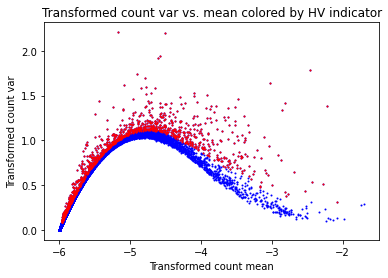

In [50]:
# --- DETECT HVG ---


# ** compute the pearson residuals **
est_std = (np.mean((X_transformed_var - pred_var)**2)) ** 0.5
pearson_residuals = (X_transformed_var - pred_var) / est_std

# ** get the hv gene indices **
hv_gene_indices = np.where(pearson_residuals >= std_residual_threshold)[0]


# ** viz **
plt.clf()
plt.scatter(X_transformed_mean,X_transformed_var,s=1,c='b')
plt.scatter(X_transformed_mean[hv_gene_indices],X_transformed_var[hv_gene_indices],s=1,c='r')
plt.title("Transformed count var vs. mean colored by HV indicator")
plt.xlabel("Transformed count mean")
plt.ylabel("Transformed count var")
# plt.savefig("/users/benauerbach/desktop/hv_fig.png",dpi=200)
plt.show()


# ** get hv gene names **
hv_genes = np.array(adata.var_names[hv_gene_indices])



In [53]:
# --- MAKE HVG DF ---

hvg_df = pd.DataFrame()
hvg_df['gene'] = list(adata.var_names)
hvg_df['transformed_mean'] = X_transformed_mean
hvg_df['transformed_var'] = X_transformed_var
hvg_df['pearson_residual'] = pearson_residuals
hvg_df['is_hvg'] = pearson_residuals >= std_residual_threshold
hvg_df = hvg_df.set_index("gene")
hvg_df = hvg_df.sort_values(['pearson_residual'], ascending=False)
hvg_df



,transformed_mean,transformed_var,pearson_residual,is_hvg
gene,,,,
Tagln,-2.464423,1.789452,24.806728,True
Myh11,-3.022667,1.639940,22.876583,True
Dcn,-5.173079,2.206513,22.484126,True
Rgs5,-4.508454,2.193962,20.813957,True
Tpm2,-2.813261,1.414636,20.475410,True
...,...,...,...,...
Pfdn5,-3.319439,0.305485,-4.167452,False
Sem1,-3.429635,0.368332,-4.187157,False
Gabarap,-3.425892,0.361517,-4.281430,False


In [63]:
# --- WRITE OUT ---

# set folder out
folder_out = '%s/Dropbox/aorta_circadian_data/datasets/joint/data_annotations/hvg/transformed_X_outlier_variance' % (head_path)
if not os.path.exists(folder_out):
    os.makedirs(folder_out)

# write hvg_df
fileout = '%s/transformed_pearson_residual.tsv' % folder_out
hvg_df.to_csv(fileout,sep='\t')

# write hvg
hvg = list(hv_genes)
fileout = '%s/hvg.txt' % folder_out
with open(fileout,'wb') as file_obj:
    file_obj.write("\n".join(hvg).encode())

# write the config dict
config = {
    'adata_path' : adata_path,
    'min_cell_count' : min_cell_count,
    'min_marker_prop' : min_marker_prop,
    'transformed_min_prop' : transformed_min_prop,
    'kernel_bandwidth' : kernel_bandwidth,
    'std_residual_threshold' : std_residual_threshold
}
    
fileout = '%s/config.txt' % (folder_out)
with open(fileout,"wb") as file_obj:
    file_obj.write(str(config).encode())
    
    
